In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Add project root to sys.path
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

from scripts.preprocessing import AutomatedPreprocessor

#here we import and split the data
df = pd.read_csv("../data/mock/new/data.csv")

#TODO we should consider where to drop the unnecessary columns

TARGET_COLUMN = "rating"
columns_to_ignore = [TARGET_COLUMN, "timePeriod", "session_id", "sent_at", "date", "Date", "id"]

feature_columns = [
    column for column in df.columns
    if column not in columns_to_ignore and pd.api.types.is_numeric_dtype(df[column])
]

X = df[feature_columns].copy()
y = df[TARGET_COLUMN].copy()

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

# Usage from scripts/
preprocessor = AutomatedPreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed Train Shape: {X_train_processed.shape}")
print(f"Processed Test Shape: {X_test_processed.shape}")

Processed Train Shape: (1704, 9)
Processed Test Shape: (533, 9)


C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\piotr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
C:\Us

Best Parameters (optimized for MSE): {'alpha': 0.001, 'l1_ratio': 0.3}
5-Fold CV Accuracies for Best Model: ['83.87%', '81.23%', '81.52%', '83.28%', '78.24%']
Mean CV Accuracy: 81.63% (std: 1.97%)

Generalized Linear Regression Results:
Train Accuracy: 81.51%
Validation Accuracy: 81.73%
Validation Mean Squared Error: 0.1761
Validation R2 Score: 0.4248


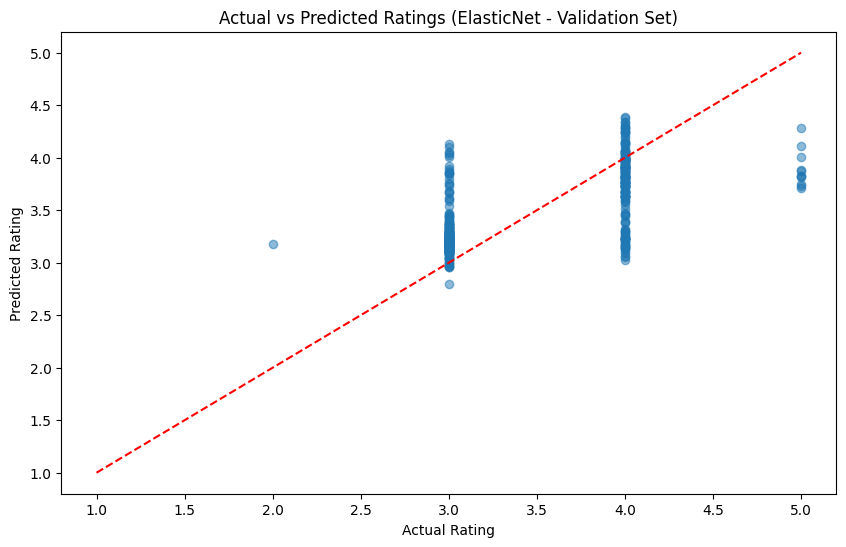

In [9]:
# Linear Regression with ElasticNet (Ridge + Lasso penalties)

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, make_scorer
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore convergence warnings that occur when alpha=0 (no penalty)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Preprocess validation set
X_val_processed = preprocessor.transform(X_val)

# Handle bounds and round for classification-like accuracy
def get_rounded_acc(y_true, y_pred_cont):
    clipped = np.clip(y_pred_cont, 1, 5)
    rounded = np.round(clipped).astype(int)
    return accuracy_score(y_true, rounded)

# Create a custom scorer to track accuracy during Cross-Validation
rounded_acc_scorer = make_scorer(get_rounded_acc)

# 1. Hyperparameter tuning for both Ridge (L2) and Lasso (L1) aspects
param_grid = {
    'alpha': [0.0, 0.001, 0.01, 0.1, 1.0, 10.0], # 0.0 = no penalty (standard linear regression)
    'l1_ratio': [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0] # 0.0 = pure Ridge, 1.0 = pure Lasso
}

elastic_net = ElasticNet(max_iter=10000)

# Evaluate using BOTH Mean Squared Error and Custom Accuracy during CV
grid_search = GridSearchCV(
    elastic_net, 
    param_grid, 
    cv=5, 
    scoring={'neg_MSE': 'neg_mean_squared_error', 'Accuracy': rounded_acc_scorer},
    refit='neg_MSE' # We still optimize hyperparameters to minimize MSE
)
grid_search.fit(X_train_processed, y_train)

best_model = grid_search.best_estimator_
best_index = grid_search.best_index_
print(f"Best Parameters (optimized for MSE): {grid_search.best_params_}")

# Display the 5-fold CV accuracies for the best performing model
cv_accuracies = [
    grid_search.cv_results_[f'split{i}_test_Accuracy'][best_index] 
    for i in range(5)
]
print(f"5-Fold CV Accuracies for Best Model: {[f'{acc*100:.2f}%' for acc in cv_accuracies]}")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies)*100:.2f}% (std: {np.std(cv_accuracies)*100:.2f}%)")

# 2. Predict on Train and Validation sets
y_train_pred_cont = best_model.predict(X_train_processed)
y_val_pred_cont = best_model.predict(X_val_processed)

# 3. Metrics Evaluated on Train and Validation Set
acc_train = get_rounded_acc(y_train, y_train_pred_cont)
acc_val = get_rounded_acc(y_val, y_val_pred_cont)
mse = mean_squared_error(y_val, y_val_pred_cont)
r2 = r2_score(y_val, y_val_pred_cont)

print(f"\nGeneralized Linear Regression Results:")
print(f"Train Accuracy: {acc_train * 100:.2f}%")
print(f"Validation Accuracy: {acc_val * 100:.2f}%")
print(f"Validation Mean Squared Error: {mse:.4f}")
print(f"Validation R2 Score: {r2:.4f}")

# Plotting actual vs predicted (Validation Set)
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_val_pred_cont, alpha=0.5)
plt.plot([1, 5], [1, 5], '--r')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (ElasticNet - Validation Set)")
plt.show()